In [1]:
import os
import pandas as pd
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
get_base_dir = os.path.abspath(os.path.join(os.getcwd(), '../../data/raw/3340_giza'))
csv_file = 'Employee Plans.csv'
absolute_path = os.path.join(get_base_dir, csv_file)

df_plans = pd.read_csv(absolute_path)
print(df_plans.head(3))

   TenantId      Id                 FromDate                   ToDate  \
0      3340  204518  2024-06-01 00:00:00.000  2024-07-10 00:00:00.000   
1      3340  208966  2024-07-11 00:00:00.000  2026-12-31 00:00:00.000   
2      3340  204477  2024-06-01 00:00:00.000  2026-12-31 00:00:00.000   

   EmployeeId  PlanId  
0       52524    4710  
1       52524    4708  
2       52528    4705  


In [3]:

get_base_dir = os.path.abspath(os.path.join(os.getcwd(), '../../data/processed/3340_giza'))
csv_file = '3340_giza_transformation_data.csv'
absolute_path = os.path.join(get_base_dir, csv_file)

df = pd.read_csv(absolute_path)

# Merge the datasets on 'EmployeeId' 
merged_df = pd.merge(df, df_plans[['EmployeeId', 'PlanId']], on='EmployeeId', how='inner')
print(merged_df.head(3))

   EmployeeId   Transdate  DayOfWeek CheckInTime CheckOutTime     hours  \
0       52524  2024-06-02          6    09:00:00     17:34:00  8.566667   
1       52524  2024-06-02          6    09:00:00     17:34:00  8.566667   
2       52524  2024-06-03          6    09:50:00     18:39:00  8.816667   

   PlanId  
0    4710  
1    4708  
2    4710  


C:\Users\fzmaj\AppData\Local\Temp\ipykernel_24764\2367432055.py:7: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  merged_df['CheckInHour'] = pd.to_datetime(merged_df['CheckInTime']).dt.hour
C:\Users\fzmaj\AppData\Local\Temp\ipykernel_24764\2367432055.py:8: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  merged_df['CheckOutHour'] = pd.to_datetime(merged_df['CheckOutTime']).dt.hour


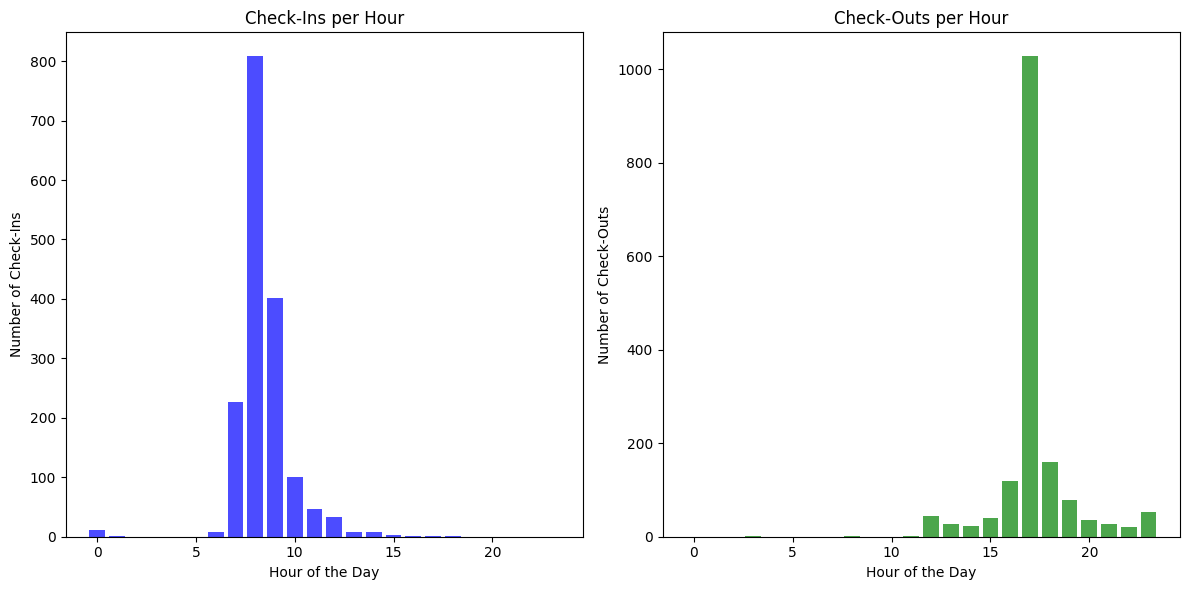

In [4]:

# Convert CheckInTime to minutes since midnight
def time_to_minutes(t):
    h, m, s = map(int, t.split(':'))
    return h * 60 + m + s / 60  # Convert seconds to minutes

# Convert 'CheckInTime' and 'CheckOutTime' from HH:MM format to minutes since midnight
merged_df['CheckInHour'] = pd.to_datetime(merged_df['CheckInTime']).dt.hour 
merged_df['CheckOutHour'] = pd.to_datetime(merged_df['CheckOutTime']).dt.hour 


merged_df['CheckInMinutes'] = merged_df['CheckInTime'].apply(time_to_minutes)
merged_df['CheckOutMinutes'] = merged_df['CheckOutTime'].apply(time_to_minutes)

# Count check-ins per hour
check_in_counts = merged_df['CheckInHour'].value_counts().sort_index()

# Count check-outs per hour
check_out_counts = merged_df['CheckOutHour'].value_counts().sort_index()

# Create a DataFrame for plotting
hours = range(24)
check_in_counts = check_in_counts.reindex(hours, fill_value=0)
check_out_counts = check_out_counts.reindex(hours, fill_value=0)

# Plot results
plt.figure(figsize=(12, 6))

# Plot Check-In counts
plt.subplot(1, 2, 1)
plt.bar(check_in_counts.index, check_in_counts.values, color='blue', alpha=0.7)
plt.xlabel('Hour of the Day')
plt.ylabel('Number of Check-Ins')
plt.title('Check-Ins per Hour')

# Plot Check-Out counts
plt.subplot(1, 2, 2)
plt.bar(check_out_counts.index, check_out_counts.values, color='green', alpha=0.7)
plt.xlabel('Hour of the Day')
plt.ylabel('Number of Check-Outs')
plt.title('Check-Outs per Hour')

plt.tight_layout()
plt.show()


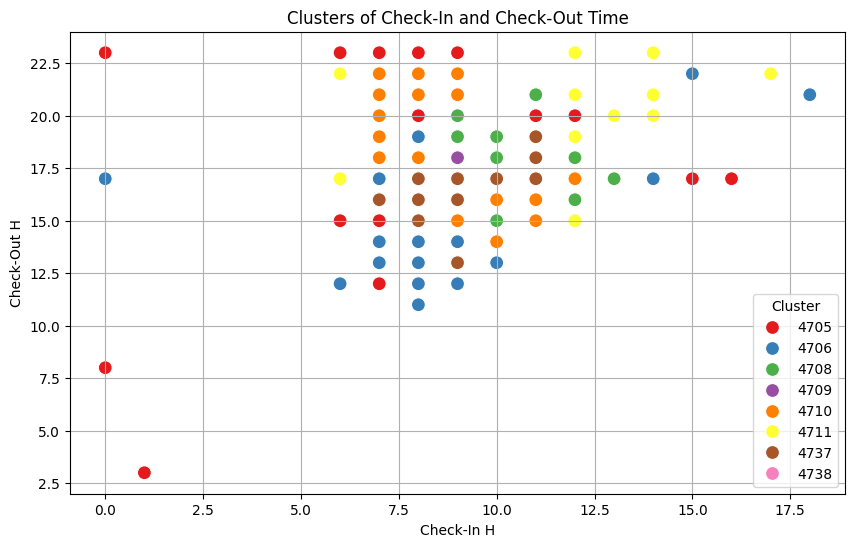

In [5]:

plt.figure(figsize=(10, 6))
sns.scatterplot(x='CheckInHour', y='CheckOutHour', hue=merged_df['PlanId'], data=merged_df, palette='Set1', s=100)
plt.title('Clusters of Check-In and Check-Out Time')
plt.xlabel('Check-In H')
plt.ylabel('Check-Out H')
plt.legend(title='Cluster')
plt.grid(True)
plt.show()

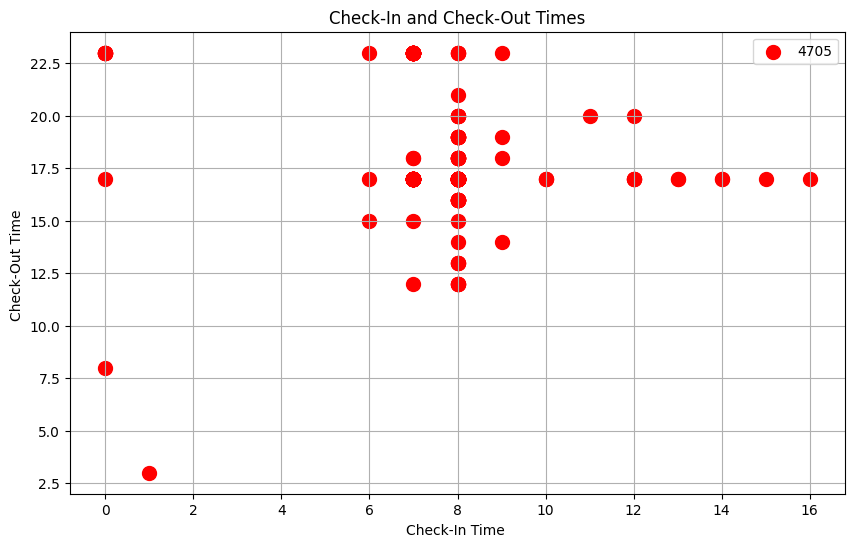

In [6]:

cluster_df = merged_df[merged_df['PlanId'] == 4705] #  "خطة  وردية نمطي من 8:30 الي 17:00 بدون راحة ثابتة "
#print(cluster_df['EmployeeId'].groupby)
plt.figure(figsize=(10, 6))
plt.scatter(cluster_df['CheckInHour'], cluster_df['CheckOutHour'], color='red', label='4705', s=100)
plt.title('Check-In and Check-Out Times')
plt.xlabel('Check-In Time ')
plt.ylabel('Check-Out Time ')
plt.grid(True)
plt.legend()
plt.show()

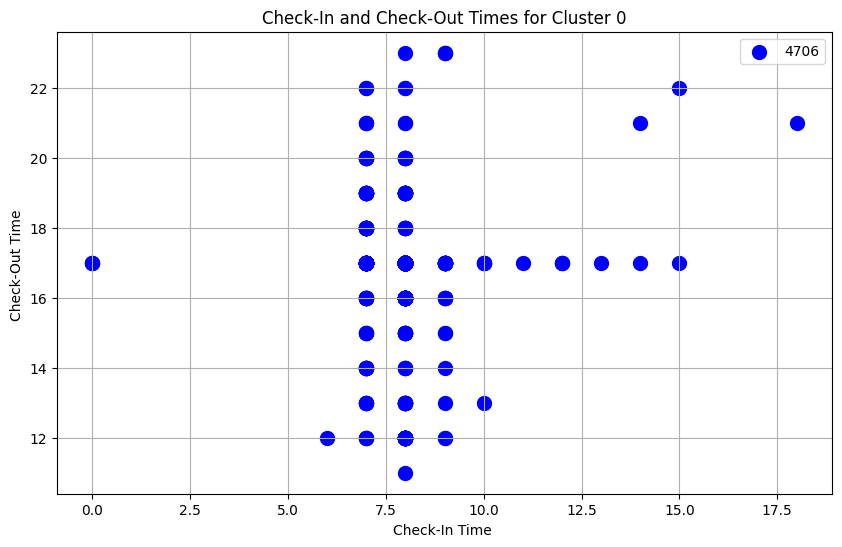

In [7]:

cluster_df = merged_df[merged_df['PlanId'] == 4706] #"خطة   نمطي من 8:30 الي 17:00 خميس نصف يوم و راحة جمعة "

plt.figure(figsize=(10, 6))
plt.scatter(cluster_df['CheckInHour'], cluster_df['CheckOutHour'], color='blue', label='4706', s=100)
plt.title('Check-In and Check-Out Times for Cluster 0')
plt.xlabel('Check-In Time ')
plt.ylabel('Check-Out Time ')
plt.grid(True)
plt.legend()
plt.show()

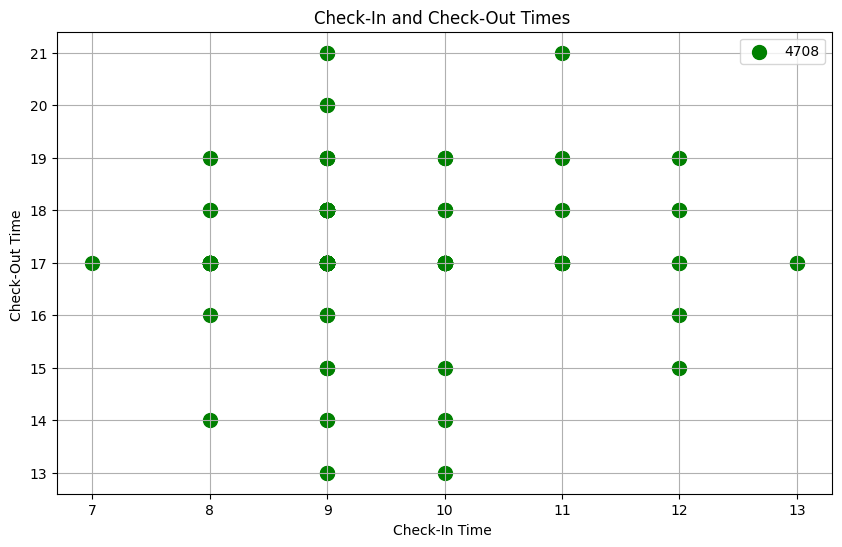

In [8]:

cluster_df = merged_df[merged_df['PlanId'] == 4708] #"خطة   نمطي من 9:00 الي 17:00 خميس نصف يوم و راحة جمعة "

plt.figure(figsize=(10, 6))
plt.scatter(cluster_df['CheckInHour'], cluster_df['CheckOutHour'], color='green', label='4708', s=100)
plt.title('Check-In and Check-Out Times ')
plt.xlabel('Check-In Time ')
plt.ylabel('Check-Out Time ')
plt.grid(True)
plt.legend()
plt.show()

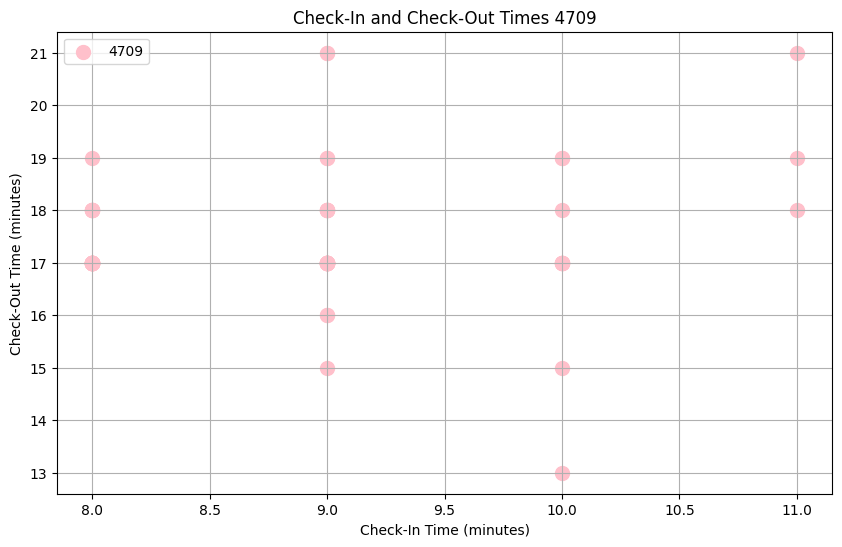

In [9]:
# Filter the DataFrame for Cluster 0
cluster_df = merged_df[merged_df['PlanId'] == 4709] #"خطة   نمطي من 9:00 الي 17:30  راحة خميس و جمعة "

plt.figure(figsize=(10, 6))
plt.scatter(cluster_df['CheckInHour'], cluster_df['CheckOutHour'], color='pink', label='4709', s=100)
plt.title('Check-In and Check-Out Times 4709')
plt.xlabel('Check-In Time (minutes)')
plt.ylabel('Check-Out Time (minutes)')
plt.grid(True)
plt.legend()
plt.show()

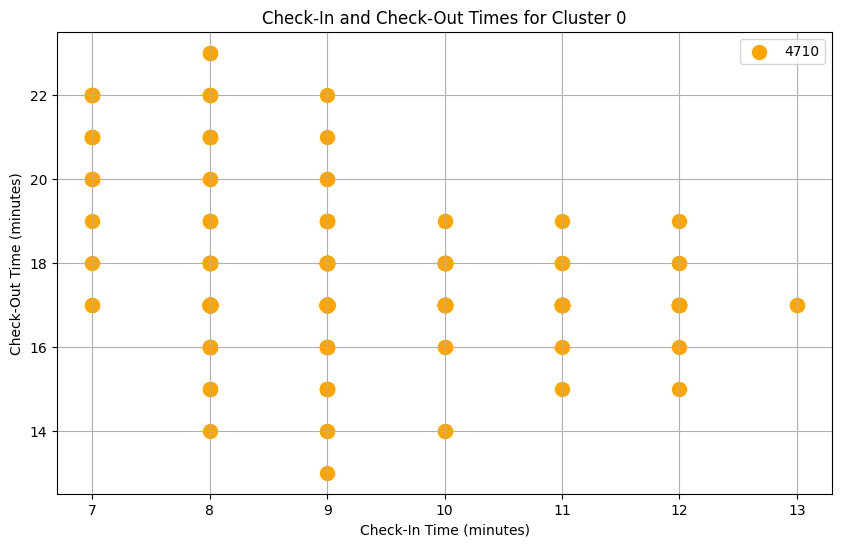

In [10]:

cluster_df = merged_df[merged_df['PlanId'] == 4710] #"خطة   نمطي من 9:00 الي 17:30  راحة جمعة ",

plt.figure(figsize=(10, 6))
plt.scatter(cluster_df['CheckInHour'], cluster_df['CheckOutHour'], color='orange', label='4710', s=100)
plt.title('Check-In and Check-Out Times for Cluster 0')
plt.xlabel('Check-In Time (minutes)')
plt.ylabel('Check-Out Time (minutes)')
plt.grid(True)
plt.legend()
plt.show()

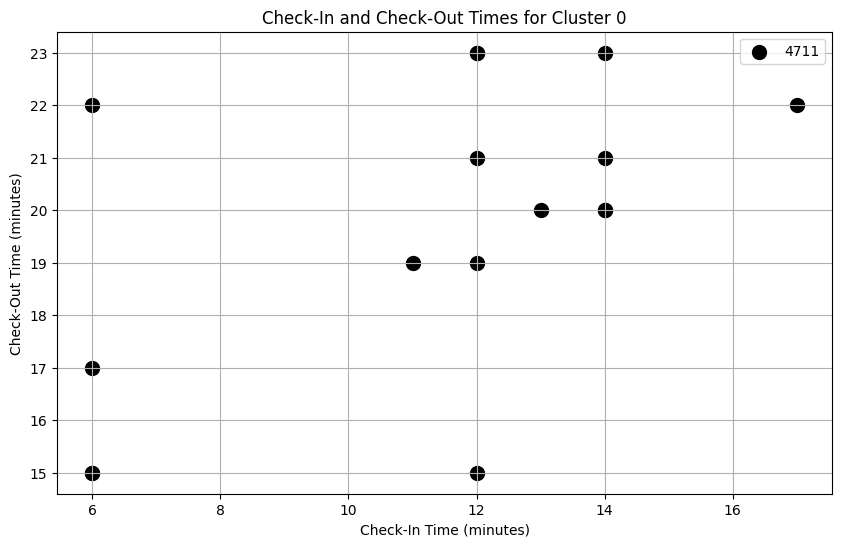

In [11]:
# Filter the DataFrame for Cluster 0
cluster_df = merged_df[merged_df['PlanId'] == 4711] # "خطة  حر حد ادني 192 س "

plt.figure(figsize=(10, 6))
plt.scatter(cluster_df['CheckInHour'], cluster_df['CheckOutHour'], color='black', label='4711', s=100)
plt.title('Check-In and Check-Out Times for Cluster 0')
plt.xlabel('Check-In Time (minutes)')
plt.ylabel('Check-Out Time (minutes)')
plt.grid(True)
plt.legend()
plt.show()

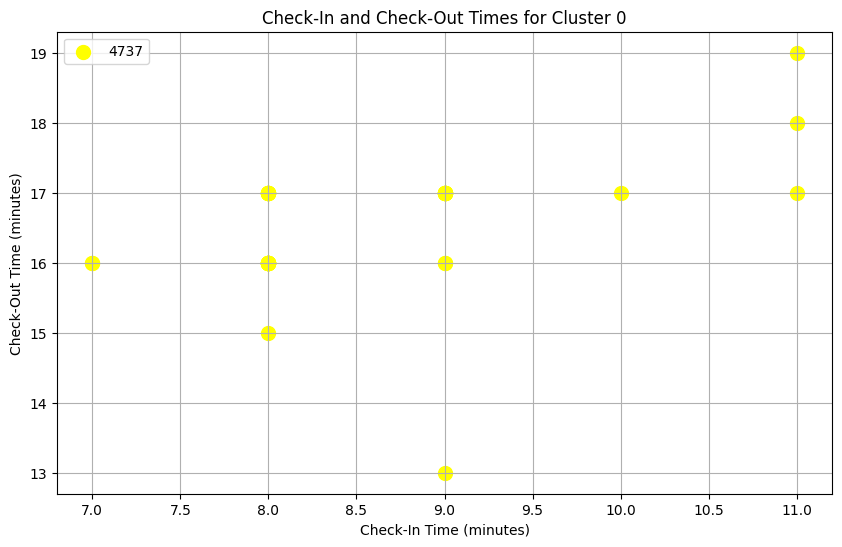

In [12]:
# Filter the DataFrame for Cluster 0
cluster_df = merged_df[merged_df['PlanId'] == 4737] # "خطة وردية حر من (8 / 17:30) 8:30 س راحة جمعة وسبت "

plt.figure(figsize=(10, 6))
plt.scatter(cluster_df['CheckInHour'], cluster_df['CheckOutHour'], color='yellow', label='4737', s=100)
plt.title('Check-In and Check-Out Times for Cluster 0')
plt.xlabel('Check-In Time (minutes)')
plt.ylabel('Check-Out Time (minutes)')
plt.grid(True)
plt.legend()
plt.show()

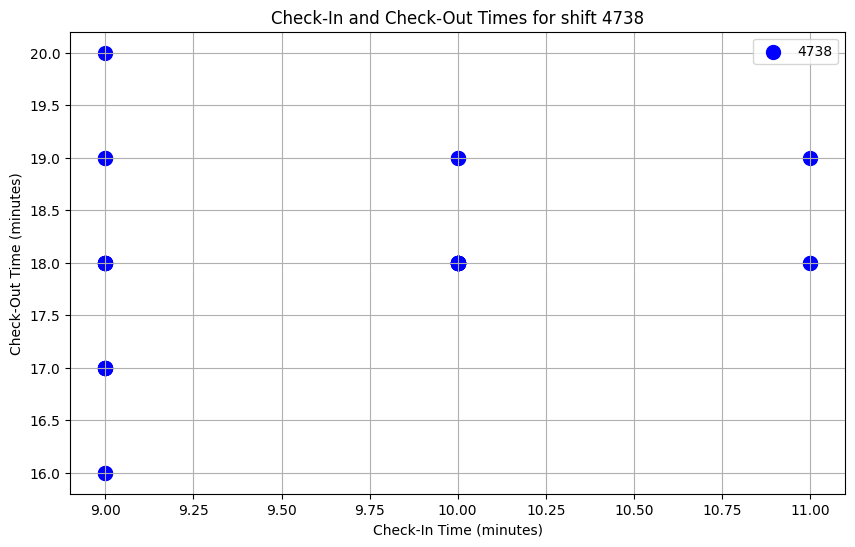

In [13]:
# Filter the DataFrame for Cluster 0
cluster_df = merged_df[merged_df['PlanId'] == 4738] # "خطة وردية حر 8 س من ( 8 / 19 ) جمعة وسبت راحة "

plt.figure(figsize=(10, 6))
plt.scatter(cluster_df['CheckInHour'], cluster_df['CheckOutHour'], color='blue', label='4738', s=100)
plt.title('Check-In and Check-Out Times for shift 4738')
plt.xlabel('Check-In Time (minutes)')
plt.ylabel('Check-Out Time (minutes)')
plt.grid(True)
plt.legend()
plt.show()

In [14]:
# Group by Cluster and EmployeeId and count the number of transactions
transaction_count = merged_df.groupby(['PlanId', 'EmployeeId']).size().reset_index(name='CheckInTime')

# Pivot to get a better view of the data
pivot_table = transaction_count.pivot(index='EmployeeId', columns='PlanId', values='CheckInTime').fillna(0)

print(pivot_table)

PlanId      4705  4706  4708  4709  4710  4711  4737  4738
EmployeeId                                                
52524        0.0   0.0  29.0   0.0  29.0   0.0   0.0   0.0
52528       31.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0
52529        0.0   0.0   0.0   0.0  35.0   0.0   0.0   0.0
52530        0.0  39.0   0.0   0.0   0.0   0.0   0.0   0.0
52531        0.0  37.0   0.0   0.0   0.0   0.0   0.0   0.0
52532       14.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0
52534        0.0   0.0  19.0   0.0   0.0   0.0   0.0   0.0
52535        0.0   0.0   0.0   0.0  26.0   0.0   0.0   0.0
52536       26.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0
52537       24.0  24.0   0.0   0.0   0.0   0.0   0.0   0.0
52538        0.0  27.0   0.0   0.0   0.0   0.0   0.0   0.0
52539        0.0   0.0   0.0   0.0  40.0   0.0   0.0   0.0
52540        0.0   0.0   0.0   0.0  41.0   0.0   0.0   0.0
52541        0.0   0.0  31.0   0.0  31.0   0.0   0.0   0.0
52542        0.0  35.0   0.0   0.0   0.0   0.0   0.0   0